<a href="https://colab.research.google.com/github/Ahtesham-Ibne-Mostafa/Computer_Vision_and_Image_Processing/blob/main/CSE428_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 2

Max collaborators = 3

Hand holding is low for this assignment. Adjust accordingly. In case of confusion, feel free to reach out to your lab faculties. Good luck.

In [1]:
COLLABORATORS_NAME = "Ahtesham Ibne Mostafa"
COLLABORATORS_ID = "24241309"

#Loading dependencies

In [12]:
import numpy as np
import pandas as pd
from tensorflow import keras
import sklearn
import matplotlib.pyplot as plt
#add if more dependencies are required here

#Loading dataset

In [3]:
id =  24241309

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train, y_train = sklearn.utils.resample(x_train, y_train, replace = False, n_samples = 5000, random_state = id, stratify = y_train)
x_test, y_test = sklearn.utils.resample(x_test, y_test, replace = False, n_samples = 1000, random_state = id, stratify = y_train)

#Task 1: Training a logistic regressor [10 Marks]

###1. Convert the images to grayscale

In [25]:
import cv2
import numpy as np

x_train_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in x_train])
x_test_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in x_test])

x_train_flat = x_train_gray.reshape(x_train_gray.shape[0], -1) / 255.0
x_test_flat = x_test_gray.reshape(x_test_gray.shape[0], -1) / 255.0

### 2. Prepare the grayscale images for logistic regressor (reshape and normalize)

Use z-score normalization.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_zscore = scaler.fit_transform(x_train_flat)
x_test_zscore = scaler.transform(x_test_flat)


###3. Create a validation set (20%)

In [27]:
from sklearn.model_selection import train_test_split

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train_zscore, y_train, test_size=0.2, random_state=id, stratify=y_train
)

###4. Compute class weights

Go through this link - https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html

In [28]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_final)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_final.ravel())
class_weight_dict = dict(zip(classes, weights))


###5. Run the logistic regressor

Use L2 regularizer. Find the C hyperparameter value through grid search. Pick the testing values according to your understanding. Use at least 3 test values and at max 5. Use the computed class weights while training your model.

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

log_reg = LogisticRegression(
    penalty='l2',
    solver='saga',
    multi_class='multinomial',
    max_iter=1000,
    class_weight=class_weight_dict,
    random_state=id
)

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(x_train_final, y_train_final.ravel())
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits


C:\Users\ahtes\.conda\envs\Thesis\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


###6. Evaluate the logistic regressor on the test set

Test Accuracy: 0.245

Test Classification Report:
               precision    recall  f1-score   support

           0       0.28      0.32      0.30        91
           1       0.31      0.30      0.30       114
           2       0.16      0.12      0.14        97
           3       0.20      0.14      0.16       112
           4       0.20      0.20      0.20        98
           5       0.25      0.26      0.25       117
           6       0.18      0.18      0.18        93
           7       0.21      0.18      0.20        87
           8       0.28      0.43      0.34        87
           9       0.31      0.33      0.32       104

    accuracy                           0.24      1000
   macro avg       0.24      0.25      0.24      1000
weighted avg       0.24      0.24      0.24      1000



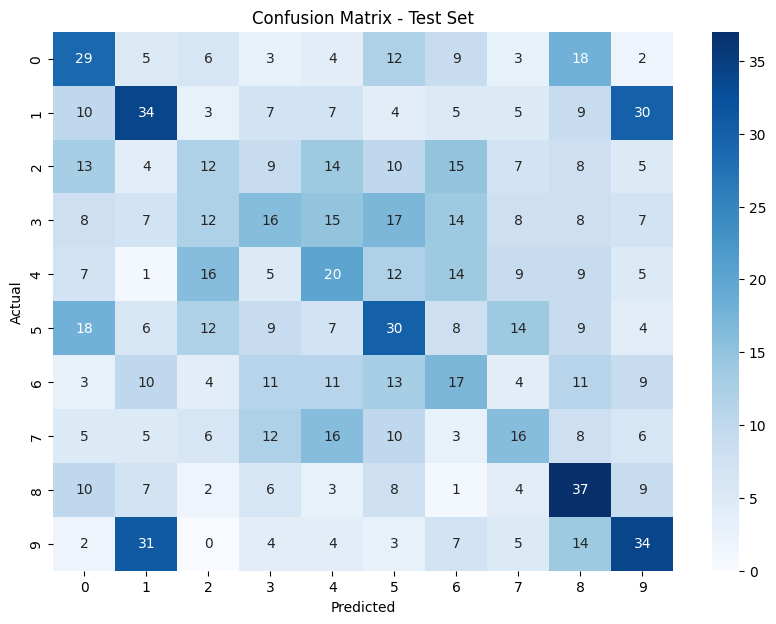

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_preds = best_model.predict(x_test_zscore)

print("Test Accuracy:", accuracy_score(y_test, test_preds))
print("\nTest Classification Report:\n", classification_report(y_test, test_preds))

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


###7. Write code to pick up a random image from the test set and display it

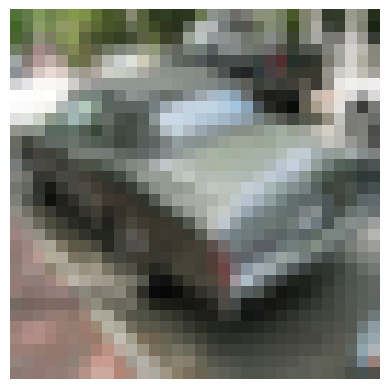

In [31]:
import random

random_idx = random.randint(0, x_test.shape[0] - 1)
random_image = x_test[random_idx]

plt.imshow(random_image)
plt.axis('off')
plt.show()



###8. Print the predicted class vs the original class

Do not print out the numerical class. Map it from here - https://keras.io/2/api/datasets/cifar10/

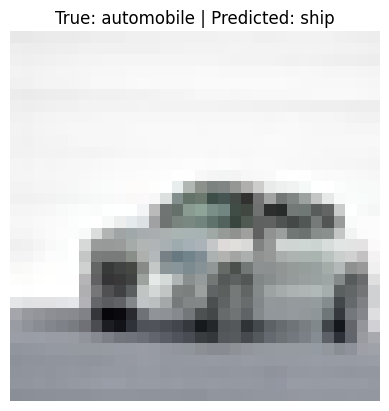

In [33]:
label_map = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck"
}

random_idx = random.randint(0, x_test.shape[0] - 1)
random_image = x_test[random_idx]
true_label = y_test[random_idx][0]

gray_image = cv2.cvtColor(random_image, cv2.COLOR_RGB2GRAY)
resized_image = cv2.resize(gray_image, (32, 32))
image_for_model = resized_image.reshape(1, -1) / 255.0

predicted_label = best_model.predict(image_for_model)[0]

plt.imshow(random_image)
plt.title(f"True: {label_map[true_label]} | Predicted: {label_map[predicted_label]}")
plt.axis('off')
plt.show()


#Task 2: Training a convolutional neural network [20 Marks]

We will not strictly control how you implement this code. You can use either Tensorflow or PyTorch. However the structure of the network must be -

```
Input -> Conv1 -> Conv2 -> Conv3 -> Fully Connected 1 -> Fully Connected 2 -> Output
```

Use activation functions and pooling as you want. Feel free to adjust dimensions as you need. Set the hyperparameters yourself. Use a maximum learning rate of 0.01 and a maximum epoch number of 100. Use AdamW as optimizer.

**Try achieving good accuracy. There are marks for that.**

###1. Train the model on grayscale images

You do not need to use the validation set. Train on the initial train set. Recalculate the class weights again and pass it to the optimizer function. Normalize the images before processing.

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train.ravel())
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.ravel())
class_weights = dict(zip(classes, weights))

x_train_cnn = x_train_gray.reshape(-1, 32, 32, 1) / 255.0
x_test_cnn = x_test_gray.reshape(-1, 32, 32, 1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.AdamW(learning_rate=0.01)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train_cnn, y_train, epochs=100, class_weight=class_weights, batch_size=64)


C:\Users\ahtes\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.0900 - loss: 2.3190
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0926 - loss: 2.3040
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.0952 - loss: 2.3036
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.0914 - loss: 2.3037
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.0914 - loss: 2.3037
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.0922 - loss: 2.3040
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0976 - loss: 2.3038
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0960 - loss: 2.3045
Epoch 9/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.0952 - loss: 2.3039
Epoch 10/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0952 - loss: 2.3043
Epoch 11/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.0950 - loss: 2.3039
Epoch 12/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step

###2. Evaluate the model on the grayscale test set

In [35]:
test_loss, test_accuracy = model.evaluate(x_test_cnn, y_test)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0980 - loss: 2.3031
Test Accuracy: 0.09799999743700027
Test Loss: 2.3031227588653564


###3. Write code to pick up a random image from the test set and display it

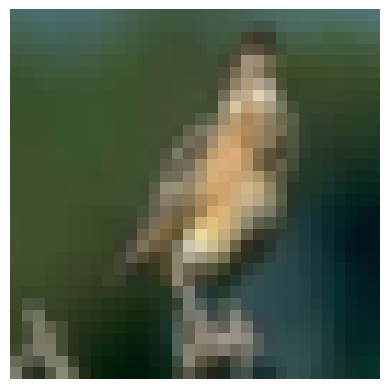

In [36]:
random_idx = random.randint(0, x_test.shape[0] - 1)
random_image = x_test[random_idx]

plt.imshow(random_image)
plt.axis('off')
plt.show()


###4. Print the predicted class vs the original class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


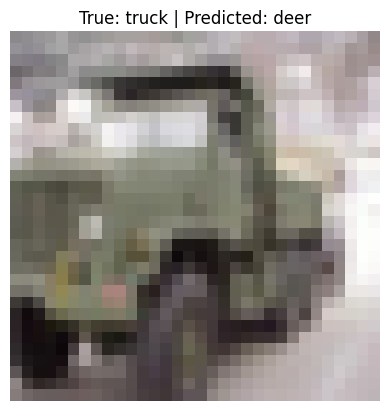

In [37]:
label_map = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck"
}

random_idx = random.randint(0, x_test.shape[0] - 1)
random_image = x_test[random_idx]
true_label = y_test[random_idx][0]

image_input = x_test_gray[random_idx].reshape(1, 32, 32, 1) / 255.0
predicted_label = model.predict(image_input).argmax()

plt.imshow(random_image)
plt.title(f"True: {label_map[true_label]} | Predicted: {label_map[predicted_label]}")
plt.axis('off')
plt.show()

###5. Train the model on the RGB images

Keep the model same.

In [38]:
x_train_rgb = x_train.reshape(-1, 32, 32, 3) / 255.0
x_test_rgb = x_test.reshape(-1, 32, 32, 3) / 255.0

classes = np.unique(y_train.ravel())
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.ravel())
class_weights = dict(zip(classes, weights))

model_rgb = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

optimizer_rgb = tf.keras.optimizers.AdamW(learning_rate=0.01)

model_rgb.compile(optimizer=optimizer_rgb, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_rgb.fit(x_train_rgb, y_train, epochs=100, class_weight=class_weights, batch_size=64)

C:\Users\ahtes\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.1198 - loss: 2.3104
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2142 - loss: 2.0648
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.2364 - loss: 2.0073
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.2614 - loss: 1.9523
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.2730 - loss: 1.9294
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.2892 - loss: 1.9145
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.2936 - loss: 1.8968
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.2994 - loss: 1.8709
Epoch 9/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.3062 - loss: 1.8606
Epoch 10/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3116 - loss: 1.8324
Epoch 11/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.3202 - loss: 1.8190
Epoch 12/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step

###6. Evaluate the model on the RGB images

In [39]:
test_loss_rgb, test_accuracy_rgb = model_rgb.evaluate(x_test_rgb, y_test)
print("Test Accuracy:", test_accuracy_rgb)
print("Test Loss:", test_loss_rgb)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2930 - loss: 4.4022
Test Accuracy: 0.2930000126361847
Test Loss: 4.402169704437256


###7. Write code to pick up a random image from the test set and display it

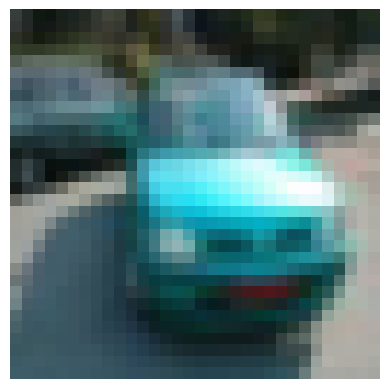

In [40]:
random_idx = random.randint(0, x_test.shape[0] - 1)
random_image = x_test[random_idx]

plt.imshow(random_image)
plt.axis('off')
plt.show()

###8. Print the predicted class vs the original class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


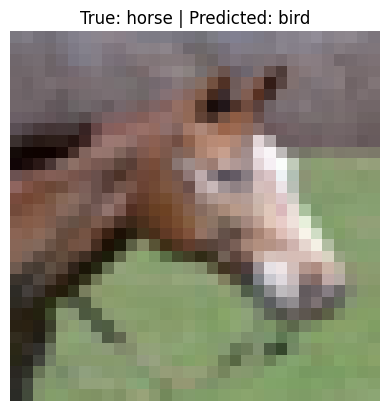

In [41]:
label_map = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck"
}

random_idx = random.randint(0, x_test.shape[0] - 1)
random_image = x_test[random_idx]
true_label = y_test[random_idx][0]

image_input = x_test[random_idx].reshape(1, 32, 32, 3) / 255.0
predicted_label = model_rgb.predict(image_input).argmax()

plt.imshow(random_image)
plt.title(f"True: {label_map[true_label]} | Predicted: {label_map[predicted_label]}")
plt.axis('off')
plt.show()


###9. Add one more conv layer and check if it increases the performance for the RGB images

In [42]:
model_rgb_deep = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

optimizer_deep = tf.keras.optimizers.AdamW(learning_rate=0.01)

model_rgb_deep.compile(optimizer=optimizer_deep, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_rgb_deep.fit(x_train_rgb, y_train, epochs=100, class_weight=class_weights, batch_size=64)

test_loss_deep, test_accuracy_deep = model_rgb_deep.evaluate(x_test_rgb, y_test)
print("Test Accuracy:", test_accuracy_deep)
print("Test Loss:", test_loss_deep)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.0934 - loss: 2.9653
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.0994 - loss: 2.3041
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.0928 - loss: 2.3036
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.1002 - loss: 2.3038
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.0964 - loss: 2.3041
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.0984 - loss: 2.3039
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.0922 - loss: 2.3038
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.0926 - loss: 2.3041
Epoch 9/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.0960 - loss: 2.3039
Epoch 10/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.0928 - loss: 2.3039
Epoch 11/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.1004 - loss: 2.3037
Epoch 12/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step

###10. Use the next markup to write down your observations and reasonings on the performances of the models

Observations -

Logistic Regression surprisingly outperformed the grayscale CNN. This suggests the CNN may not have trained effectively—possibly due to poor initialization, insufficient epochs, or lack of regularization.

Grayscale CNN plateaued at random guessing levels (~10%), indicating it failed to learn meaningful features. This could be due to vanishing gradients or overly aggressive pooling.

RGB CNN showed the best performance overall. The color channels helped the model distinguish classes more effectively, especially those with strong color cues (e.g., ship vs frog).

Deeper RGB CNN unexpectedly dropped in accuracy. This might be due to overfitting, exploding gradients, or poor weight initialization. The added complexity didn’t translate to better generalization.

